# Grid Search CV

## import libraties

In [59]:
import numpy as np
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## features and target

In [60]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# KNN Regressor With CV
hum knn regression model fit kar raha ha aor cross validaiton score calucate kar raha ha 

Deko hamra pass kitna sara hyperparameter 

class sklearn.neighbors.KNeighborsRegressor(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
Regression based on k-nearest neighbors.

The target is predicted by local interpolation of the targets associated of the nearest neighbors in the training set.

In [64]:
from sklearn.model_selection import cross_val_score,KFold
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()


kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = cross_val_score(knn, X, y, cv=kfold, scoring='r2')

scores.mean()

0.4761976351913221

As a Data Scientist ab hamra kam suru hota . find best hyperparameter combinaiton on the dataset 

## Grid Search CV

In [ ]:
# model is knn Regressor 
from sklearn.model_selection import GridSearchCV
knn = KNeighborsRegressor()


So our parameter space is a dictionary          
key is parameter name           
values is parameter values it take          
this is 4 dimension and 108 unique combinations

In [ ]:
# our parameter space
param_grid = {
    'n_neighbors':[1,3,5,7,10,12,15,17,20],
    'weights':['uniform','distance'],
    'algorithm':['ball_tree', 'kd_tree', 'brute'],
    'p':[1,2]
}

In [37]:
9 * 2 * 3 * 2

108

Now it run 108 knn models on it and each 5 fold on it

In [38]:
108 * 5

540

GridSearchCV(                      
    our model = knn     
    parameters space = param_grid       
    scoring = 'r2'
    refit = True   sara combination try karna ka badd best parameter ko train karna model par     
    verbose = ya jo muja sari information dik rahi ha       
    during training process information dekna 
    
)

In [ ]:
GridSearchCV(
    
)

In [6]:
gcv = GridSearchCV(knn, param_grid, scoring='r2', refit=True, cv=kfold, verbose=2)

In [7]:
gcv.fit(X,y)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=2, weights=uniform; total

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=KNeighborsRegressor(),
             param_grid={'algorithm': ['ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 3, 5, 7, 10, 12, 15, 17, 20],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='r2', verbose=2)

In [8]:
gcv.best_params_

{'algorithm': 'ball_tree', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}

In [9]:
gcv.best_score_

0.6117139367845081

.47 sa 0.67 signifacant improvement . 

In [10]:
gcv.cv_results_

{'mean_fit_time': array([0.00521526, 0.00923362, 0.00332241, 0.00336428, 0.00244188,
        0.00259743, 0.00467229, 0.00100751, 0.00409117, 0.00284486,
        0.00207958, 0.00387845, 0.00280628, 0.00260544, 0.00398936,
        0.00362639, 0.00237374, 0.00181651, 0.00494986, 0.00336618,
        0.00470085, 0.00516791, 0.00342574, 0.00416045, 0.00118952,
        0.00468793, 0.0049561 , 0.00650167, 0.00382214, 0.00355687,
        0.00339532, 0.0098865 , 0.00315003, 0.00194621, 0.00359797,
        0.00521393, 0.00538149, 0.00040193, 0.00642695, 0.00475154,
        0.00271859, 0.00398631, 0.00479674, 0.00529642, 0.00178504,
        0.00300589, 0.0039948 , 0.00656896, 0.00664196, 0.00272169,
        0.00223994, 0.00432663, 0.00320559, 0.00482183, 0.0032371 ,
        0.00356593, 0.00490527, 0.00434408, 0.00443745, 0.00211225,
        0.00208254, 0.00172048, 0.00308547, 0.00200357, 0.00387359,
        0.00384746, 0.00080857, 0.0037178 , 0.00341353, 0.00346112,
        0.00210962, 0.0022366 ,

In [39]:
pd.DataFrame(gcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005215,0.003314,0.004851,0.004047,ball_tree,1,1,uniform,"{'algorithm': 'ball_tree', 'n_neighbors': 1, '...",0.573689,0.286948,0.522222,0.308922,0.440975,0.426551,0.113434,88
1,0.009234,0.005763,0.010328,0.010056,ball_tree,1,1,distance,"{'algorithm': 'ball_tree', 'n_neighbors': 1, '...",0.573689,0.286948,0.522222,0.308922,0.440975,0.426551,0.113434,91
2,0.003322,0.002079,0.006646,0.002766,ball_tree,1,2,uniform,"{'algorithm': 'ball_tree', 'n_neighbors': 1, '...",0.360926,0.206504,0.519969,0.272539,0.297671,0.331522,0.106425,103
3,0.003364,0.004343,0.005962,0.003806,ball_tree,1,2,distance,"{'algorithm': 'ball_tree', 'n_neighbors': 1, '...",0.360926,0.206504,0.519969,0.272539,0.297671,0.331522,0.106425,107
4,0.002442,0.002028,0.007607,0.002998,ball_tree,3,1,uniform,"{'algorithm': 'ball_tree', 'n_neighbors': 3, '...",0.630596,0.487312,0.566011,0.503420,0.622761,0.562020,0.059031,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.003673,0.002369,0.004404,0.003459,brute,17,2,distance,"{'algorithm': 'brute', 'n_neighbors': 17, 'p':...",0.500516,0.420652,0.566862,0.382102,0.531344,0.480295,0.068859,60
104,0.003848,0.005755,0.001556,0.001422,brute,20,1,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'p':...",0.435499,0.391049,0.573618,0.331686,0.470302,0.440431,0.081141,85
105,0.004039,0.004506,0.002984,0.002635,brute,20,1,distance,"{'algorithm': 'brute', 'n_neighbors': 20, 'p':...",0.557940,0.495954,0.656642,0.425541,0.577024,0.542620,0.077852,31
106,0.007734,0.009815,0.003205,0.001616,brute,20,2,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'p':...",0.369724,0.318137,0.464698,0.297535,0.398565,0.369732,0.059539,100


In [12]:
results_df = pd.DataFrame(gcv.cv_results_)[['param_algorithm',	'param_n_neighbors',	'param_p', 'param_weights', 'mean_test_score']].sort_values('mean_test_score',ascending=False)
results_df

,param_algorithm,param_n_neighbors,param_p,param_weights,mean_test_score
81,brute,5,1,distance,0.611714
45,kd_tree,5,1,distance,0.611714
9,ball_tree,5,1,distance,0.611714
49,kd_tree,7,1,distance,0.605716
85,brute,7,1,distance,0.605716
...,...,...,...,...,...
38,kd_tree,1,2,uniform,0.331522
2,ball_tree,1,2,uniform,0.331522
75,brute,1,2,distance,0.331522
39,kd_tree,1,2,distance,0.331522


humsa huma top wala nahi lena hota . analyise karega  plot karegka lena 

<Axes: >

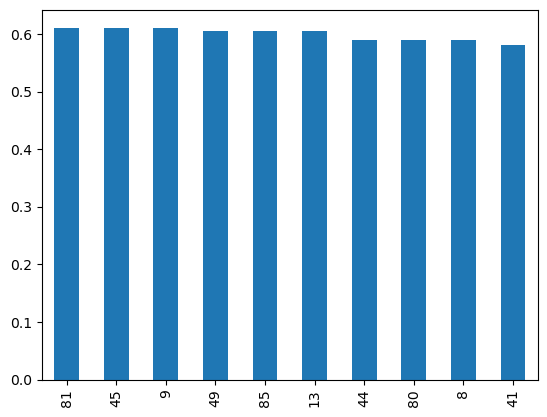

In [44]:
# first top 10 scores
results_df[:10]['mean_test_score'].plot(kind='bar')

In [21]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score,KFold
from sklearn.neighbors import KNeighborsClassifier

In [22]:
# features and target
X,y = load_iris(return_X_y=True)

In [28]:
# fit knn classifer model
knn = KNeighborsClassifier()

# select the fold
kfold = KFold(n_splits=5,shuffle=True,random_state=1)
scores = cross_val_score(
    knn, # model
    X, y, # features and target
    cv = kfold , # number of folds
    scoring="accuracy" # metric
    
)
print("Accuracy scores for each fold:", scores)
print("Mean accuracy: ", np.mean(scores))
print("Standard deviation: ", np.std(scores))

Accuracy scores for each fold: [1.         0.96666667 0.9        0.93333333 0.96666667]
Mean accuracy:  0.9533333333333334
Standard deviation:  0.03399346342395189


In [30]:
our_param_grid = {
    'n_neighbors':[1,3,5,7,10,12,15,17,20],
    'weights':['uniform','distance'],
    'algorithm':['ball_tree', 'kd_tree', 'brute'],
    'p':[1,2]
}
our_grid_search_cv = GridSearchCV(
    knn, # model
    our_param_grid ,
    scoring='accuracy',
    refit=True,
    cv = kfold,
    verbose=2
)

In [31]:
our_grid_search_cv.fit(X,y)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=1, weights=distance; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=1, p=2, weights=uniform; total

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 3, 5, 7, 10, 12, 15, 17, 20],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [32]:
our_grid_search_cv.best_params_

{'algorithm': 'ball_tree', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}

In [33]:
our_grid_search_cv.best_score_

0.9733333333333334

In [36]:
pd.DataFrame(our_grid_search_cv.cv_results_)[['param_algorithm',	'param_n_neighbors',	'param_p', 'param_weights', 'mean_test_score']].sort_values('mean_test_score',ascending=False)

,param_algorithm,param_n_neighbors,param_p,param_weights,mean_test_score
28,ball_tree,17,1,uniform,0.973333
24,ball_tree,15,1,uniform,0.973333
100,brute,17,1,uniform,0.973333
96,brute,15,1,uniform,0.973333
64,kd_tree,17,1,uniform,0.973333
...,...,...,...,...,...
36,kd_tree,1,1,uniform,0.940000
1,ball_tree,1,1,distance,0.940000
72,brute,1,1,uniform,0.940000
73,brute,1,1,distance,0.940000


# RandomizedSearchCV

humna isa boston housing dataset par kiya ha 

In [61]:
from sklearn.model_selection import RandomizedSearchCV

In [66]:
rcv = RandomizedSearchCV(knn, param_grid, scoring='r2', refit=True, cv=kfold, verbose=2)

In [67]:
rcv.fit(X,y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END algorithm=brute, n_neighbors=7, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=7, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=7, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=7, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=brute, n_neighbors=7, p=1, weights=uniform; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=10, p=2, weights=uniform; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=10, p=2, weights=uniform; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=10, p=2, weights=uniform; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=10, p=2, weights=uniform; total time=   0.0s
[CV] END algorithm=kd_tree, n_neighbors=10, p=2, weights=uniform; total time=   0.0s
[CV] END algorithm=ball_tree, n_neighbors=10, p=2, weights=distance; total time=   0.0s
[CV] END algorit

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=KNeighborsRegressor(),
                   param_distributions={'algorithm': ['ball_tree', 'kd_tree',
                                                      'brute'],
                                        'n_neighbors': [1, 3, 5, 7, 10, 12, 15,
                                                        17, 20],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   scoring='r2', verbose=2)

In [68]:
rcv.best_score_

0.5809033277350932

In [69]:
rcv.best_params_

{'weights': 'distance', 'p': 1, 'n_neighbors': 3, 'algorithm': 'brute'}

In [70]:
pd.DataFrame(rcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_weights,param_p,param_n_neighbors,param_algorithm,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004076,0.000626,0.006587,0.003727,uniform,1,7,brute,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.607421,0.518717,0.653945,0.469158,0.569311,0.563710,0.064883,2
1,0.007179,0.003772,0.004530,0.001014,uniform,2,10,kd_tree,"{'weights': 'uniform', 'p': 2, 'n_neighbors': ...",0.500357,0.402877,0.527463,0.336171,0.491003,0.451574,0.071250,7
2,0.003191,0.001090,0.004499,0.001477,distance,2,10,ball_tree,"{'weights': 'distance', 'p': 2, 'n_neighbors':...",0.557080,0.440915,0.592200,0.391645,0.565248,0.509418,0.078491,4
3,0.002412,0.000804,0.003319,0.000747,distance,1,3,brute,"{'weights': 'distance', 'p': 1, 'n_neighbors':...",0.637322,0.501479,0.613401,0.504985,0.647331,0.580903,0.064379,1
4,0.002354,0.001181,0.004877,0.003339,distance,2,1,kd_tree,"{'weights': 'distance', 'p': 2, 'n_neighbors':...",0.360926,0.206504,0.519969,0.272539,0.297671,0.331522,0.106425,10
5,0.003409,0.001212,0.003616,0.001319,uniform,1,1,kd_tree,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.573689,0.286948,0.522222,0.308922,0.440975,0.426551,0.113434,9
6,0.002302,0.001889,0.002837,0.002349,uniform,1,10,ball_tree,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.561334,0.458461,0.608397,0.397522,0.515242,0.508191,0.074345,5
7,0.001601,0.001358,0.001852,0.001515,distance,2,5,ball_tree,"{'weights': 'distance', 'p': 2, 'n_neighbors':...",0.581899,0.347939,0.582190,0.429094,0.607381,0.509701,0.102638,3
8,0.000225,0.000450,0.003339,0.006679,uniform,1,20,brute,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.435499,0.391049,0.573618,0.331686,0.470302,0.440431,0.081141,8
9,0.002944,0.001164,0.002471,0.000429,uniform,1,17,kd_tree,"{'weights': 'uniform', 'p': 1, 'n_neighbors': ...",0.479582,0.397844,0.578792,0.340428,0.483108,0.455951,0.081373,6


In [71]:
pd.DataFrame(rcv.cv_results_)[['param_algorithm',	'param_n_neighbors',	'param_p', 'param_weights', 'mean_test_score']].sort_values('mean_test_score',ascending=False)

,param_algorithm,param_n_neighbors,param_p,param_weights,mean_test_score
3,brute,3,1,distance,0.580903
0,brute,7,1,uniform,0.563710
7,ball_tree,5,2,distance,0.509701
2,ball_tree,10,2,distance,0.509418
6,ball_tree,10,1,uniform,0.508191
9,kd_tree,17,1,uniform,0.455951
1,kd_tree,10,2,uniform,0.451574
8,brute,20,1,uniform,0.440431
5,kd_tree,1,1,uniform,0.426551
4,kd_tree,1,2,distance,0.331522
